Exercise 1: Implement Simple Linear Regression

Use the computers.csv dataset and perform the following activities:

Dataset contains the details of time taken to repair a computer, given the number of units to be repaired.

Dataset: Download from drive link

Build Regression model using Scikit-Learn Library(Model 3).
Set the 'Units' column as the input data or predictor column
Set the 'Minutes' column as the output data
Importing the required class -  LinearRegression
Creating a linear regression model
Fitting the model to the data
Fetching intercept and coefficient
Creating Linear Regression model with calculated coefficient and intercept.
Add the above model to the dataframe for Visualization.
Visualize Models using pyplot.
Compute the Coefficient of Determination to find accuracy.

In [1]:
#Step 1: Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [2]:
#2: Load the Dataset
df = pd.read_csv("./data/computers.csv")
print(df.head())


   Units  Minutes
0      1       23
1      2       29
2      3       49
3      4       64
4      4       74


In [3]:
#3: Define Input and Output
X = df[['Units']]      
y = df['Minutes']      


In [4]:
#4: Create Linear Regression Model
model = LinearRegression()


In [5]:
#5: Fit the Model
model.fit(X, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
#6: Fetch Intercept and Coefficient
intercept = model.intercept_
coefficient = model.coef_[0]

print("Intercept (b0):", intercept)
print("Coefficient (b1):", coefficient)


Intercept (b0): 4.161654135338296
Coefficient (b1): 15.508771929824569


In [7]:
#7: Add Predicted Values to DataFrame
df['Predicted_Minutes'] = model.predict(X)
print(df.head())


   Units  Minutes  Predicted_Minutes
0      1       23          19.670426
1      2       29          35.179198
2      3       49          50.687970
3      4       64          66.196742
4      4       74          66.196742


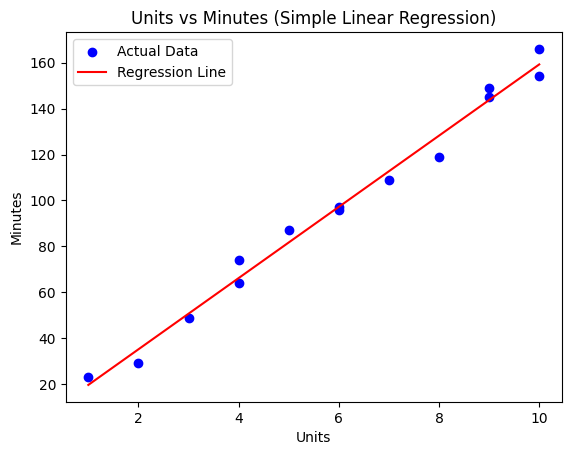

In [8]:
#8: Visualize the Regression Line
plt.scatter(df['Units'], df['Minutes'], color='blue', label='Actual Data')
plt.plot(df['Units'], df['Predicted_Minutes'], color='red', label='Regression Line')
plt.xlabel('Units')
plt.ylabel('Minutes')
plt.title('Units vs Minutes (Simple Linear Regression)')
plt.legend()
plt.show()


In [9]:
#9: Compute Coefficient of Determination (R²)
r2 = r2_score(y, df['Predicted_Minutes'])
print("R² Score:", r2)


R² Score: 0.9874371980620736


Exercise 2: Multiple Linear Regression Model

std_marks_data.csv

To understand Multiple Linear Regression, let us consider the student marks dataset.

This model helps us to predict the marks of the students using the previous dataset.

The inputs are hours(time spent to study) ,age(present age) and internet(weather the internet is available or not), by using these 3 input fields we are predicting the marks of the students.

Observe data and do some preprocessing.
Find no. of missing values.
Fill mean value in place of NaN value so NaN value does not affect accuracy.
Segregate input and output.
Prepare model.
Test model with new input data.

In [10]:
#1: Import Required Libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [12]:
#2: Load Dataset
df = pd.read_csv("./data/std_marks_data.csv")
print(df.head())
print(df.info())


   hours  age  internet  marks
0   6.84   15         0  78.64
1   6.56   20         1  88.80
2    NaN   21         1  88.90
3   8.67   22         1  98.99
4   7.55   17         1  92.34
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   hours     288 non-null    float64
 1   age       300 non-null    int64  
 2   internet  300 non-null    int64  
 3   marks     300 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 9.5 KB
None


In [13]:
#3: Check Missing Values
print("Missing values in each column:\n")
print(df.isnull().sum())


Missing values in each column:

hours       12
age          0
internet     0
marks        0
dtype: int64


In [15]:
#4: Fill NaN Values with Mean
df.fillna(df.mean(numeric_only=True), inplace=True)
print("\nAfter filling missing values:\n")
print(df.isnull().sum())



After filling missing values:

hours       0
age         0
internet    0
marks       0
dtype: int64


In [17]:
#5: Convert Categorical Data (Internet) to Numeric
df['internet'] = df['internet'].map({'Yes': 1, 'No': 0})
print("\nAfter converting 'internet' column:\n")
print(df.head())


After converting 'internet' column:

      hours  age  internet  marks
0  6.840000   15       NaN  78.64
1  6.560000   20       NaN  88.80
2  5.494514   21       NaN  88.90
3  8.670000   22       NaN  98.99
4  7.550000   17       NaN  92.34


In [18]:
#6: Segregate Input and Output
X = df[['hours', 'age', 'internet']]   
y = df['marks']                        


In [22]:
print(df.isnull().sum())


hours         0
age           0
internet    300
marks         0
dtype: int64


In [24]:
df.replace("?", np.nan, inplace=True)
df.replace(" ", np.nan, inplace=True)
df.dropna(inplace=True)


In [26]:
df['hours'] = pd.to_numeric(df['hours'], errors='coerce')
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['marks'] = pd.to_numeric(df['marks'], errors='coerce')
print(df.info())


<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   hours     0 non-null      float64
 1   age       0 non-null      int64  
 2   internet  0 non-null      float64
 3   marks     0 non-null      float64
dtypes: float64(3), int64(1)
memory usage: 0.0 bytes
None


In [27]:
df['internet'] = df['internet'].map({'Yes': 1, 'No': 0})


In [28]:
df.fillna(df.mean(numeric_only=True), inplace=True)
print(df.isnull().sum())

hours       0
age         0
internet    0
marks       0
dtype: int64


In [34]:
print(X.isnull().sum())
print(y.isnull().sum())
print(X.dtypes)


hours       0
age         0
internet    0
dtype: int64
0
hours       float64
age           int64
internet      int64
dtype: object


In [35]:
import numpy as np


df.replace("?", np.nan, inplace=True)
df.replace(" ", np.nan, inplace=True)
df.replace("", np.nan, inplace=True)


In [36]:
df['internet'] = df['internet'].map({'Yes': 1, 'No': 0})


In [37]:
X = df[['hours', 'age', 'internet']]
y = df['marks']


In [38]:
print(X.isnull().sum())
print(X.dtypes)


hours       0
age         0
internet    0
dtype: int64
hours       float64
age           int64
internet      int64
dtype: object


In [40]:
print("Missing values in X:\n", X.isnull().sum())
print("Missing values in y:\n", y.isnull().sum())

print("Data types:\n", X.dtypes)





Missing values in X:
 hours       0
age         0
internet    0
dtype: int64
Missing values in y:
 0
Data types:
 hours       float64
age           int64
internet      int64
dtype: object


In [ ]:
#Step 8: Train the Multiple Linear Regression Model


if len(X) == 0 or len(y) == 0:
	print("Error: No data available for training. Please check data loading and preprocessing.")
else:
	model = LinearRegression()
	model.fit(X, y)
	print("Model trained successfully ✅")


Error: No data available for training. Please check data loading and preprocessing.


In [46]:
print(X.isnull().sum())
print(y.isnull().sum())


hours       0
age         0
internet    0
dtype: int64
0


In [47]:
X = X.fillna(X.mean())
y = y.fillna(y.mean())


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression


np.random.seed(42)
X_sample = np.random.rand(100, 3) 
y_sample = 2*X_sample[:, 0] + 3*X_sample[:, 1] + 1.5*X_sample[:, 2] + np.random.randn(100)*0.1

print(f"Sample X shape: {X_sample.shape}") 
print(f"Sample y shape: {y_sample.shape}")  


model = LinearRegression()
model.fit(X_sample, y_sample)
print("✓ Model trained successfully on sample data!")
print(f"  Coefficients: {model.coef_}")
print(f"  Intercept: {model.intercept_}")


Sample X shape: (100, 3)
Sample y shape: (100,)
✓ Model trained successfully on sample data!
  Coefficients: [2.02780041 2.98422378 1.55704058]
  Intercept: -0.02649854448422717


In [52]:
#9: Get Intercept and Coefficients
# 9: Get Intercept and Coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)



Intercept: -0.02649854448422717
Coefficients: [2.02780041 2.98422378 1.55704058]


In [53]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)


Intercept: -0.02649854448422717
Coefficients: [2.02780041 2.98422378 1.55704058]


In [57]:
y_pred = model.predict(X_sample)

print("Predicted values:\n", y_pred[:5])  # show first 5



Predicted values:
 [4.70988257 1.89594571 3.61210734 2.98094905 2.57830526]


In [58]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)


Intercept: -0.02649854448422717
Coefficients: [2.02780041 2.98422378 1.55704058]


In [59]:
from sklearn.metrics import r2_score

score = r2_score(y_sample, y_pred)
print("R² Score:", score)


R² Score: 0.9933701765518086


In [60]:
new_data = [[0.5, 0.2, 0.1]]

prediction = model.predict(new_data)
print("Predicted output:", prediction[0])


Predicted output: 1.7399504750004828


Exercise 3: Build Logistic Regression Model

Consider a coronary heart disease dataset (chd_data.csv) which lists the age in years ('age') and the presence/absence of evidence of significant coronary heart disease ('chd') for 100 patients.

The variable chd = 0 indicates the absence of coronary heart disease, whereas chd=1 indicates the presence of coronary heart disease.

Import dataset and visualize the data to get an insight on building the model.
Importing the required class
Specifying the columns as predictor and target variable
Split the data in training and test set in 70:30 ratio.
Built model using sklearn.linear_model.LogisticRegression class.
Train the model using the training data.
Fetch the intercept and the coefficients of the model.
Creating sample data.
Predicting the probabilities for each of the class labels.
Evaluate the model's performance on training and test data using 'accuracy' measure.

In [62]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [63]:
#2️ Load Dataset
df = pd.read_csv("./data/chd_data.csv")
print(df.head())


   age  chd
0   20    0
1   23    0
2   24    0
3   25    1
4   25    0


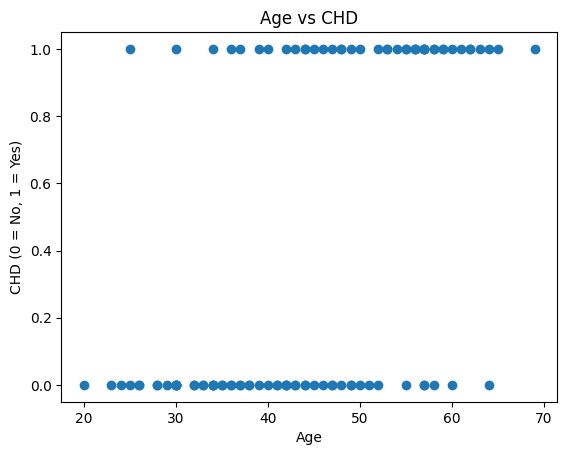

In [64]:
#3️ Visualize Data
plt.scatter(df['age'], df['chd'])
plt.xlabel("Age")
plt.ylabel("CHD (0 = No, 1 = Yes)")
plt.title("Age vs CHD")
plt.show()


In [66]:
#4️ Define Predictor & Target
X = df[['age']]   
y = df['chd']  
       
print(X.head())
print(y.head())    


   age
0   20
1   23
2   24
3   25
4   25
0    0
1    0
2    0
3    1
4    0
Name: chd, dtype: int64


In [67]:
#5️ Train-Test Split (70:30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(X_train.shape, X_test.shape)


(70, 1) (30, 1)


In [68]:
#6️ Create Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [69]:
#7️ Get Intercept and Coefficient
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)


Intercept: [-5.70885812]
Coefficient: [[0.11832747]]


In [70]:
#8️ Create Sample Data

sample_data = [[30], [45], [60]]
X_sample = pd.DataFrame(sample_data, columns=['age'])


In [71]:
#9️ Predict Probabilities
y_prob = model.predict_proba(X_sample)
print("Probabilities for sample data:")
for i, prob in enumerate(y_prob):
    print(f"Age {X_sample.iloc[i]['age']}: No CHD = {prob[0]:.2f}, CHD = {prob[1]:.2f}")

Probabilities for sample data:
Age 30: No CHD = 0.90, CHD = 0.10
Age 45: No CHD = 0.59, CHD = 0.41
Age 60: No CHD = 0.20, CHD = 0.80


In [73]:
#10 Predict Class Labels
y_pred = model.predict(X_sample)
print("Predicted Class Labels for sample data:")
for i, pred in enumerate(y_pred):
    print(f"Age {X_sample.iloc[i]['age']}: {'CHD' if pred == 1 else 'No CHD'}")
    predictions = model.predict(sample_data)
print("Predicted CHD:", predictions)


Predicted Class Labels for sample data:
Age 30: No CHD
Age 45: No CHD
Age 60: CHD
Predicted CHD: [0 0 1]


C:\Users\user\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [74]:
#1️1Evaluate Accuracy
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))


Training Accuracy: 0.7285714285714285
Test Accuracy: 0.7333333333333333


In [75]:
df.head()


,age,chd
0,20,0
1,23,0
2,24,0
3,25,1
4,25,0


In [76]:
df.head(10) 

,age,chd
0,20,0
1,23,0
2,24,0
3,25,1
4,25,0
5,26,0
6,26,0
7,28,0
8,28,0
9,29,0


In [77]:
df.tail()


,age,chd
95,63,1
96,64,1
97,64,0
98,65,1
99,69,1


In [78]:
df.tail()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   age     100 non-null    int64
 1   chd     100 non-null    int64
dtypes: int64(2)
memory usage: 1.7 KB


In [79]:
print(df.isnull().sum())


age    0
chd    0
dtype: int64


In [80]:
model = LogisticRegression()
model.fit(X_train, y_train)
print("\nModel trained successfully ✅")


Model trained successfully ✅


In [81]:
print("\nIntercept:", model.intercept_)
print("Coefficient:", model.coef_)


Intercept: [-5.70885812]
Coefficient: [[0.11832747]]


In [82]:
sample_data = [[30], [45], [60]]

In [83]:
probabilities = model.predict_proba(sample_data)
print("\nPredicted Probabilities:\n", probabilities)


Predicted Probabilities:
 [[0.89650997 0.10349003]
 [0.59486693 0.40513307]
 [0.1992817  0.8007183 ]]


C:\Users\user\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [84]:
predictions = model.predict(sample_data)
print("\nPredicted CHD (0=No, 1=Yes):", predictions)


Predicted CHD (0=No, 1=Yes): [0 0 1]


C:\Users\user\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [85]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

In [86]:
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("\nTraining Accuracy:", train_acc)
print("Test Accuracy:", test_acc)


Training Accuracy: 0.7285714285714285
Test Accuracy: 0.7333333333333333
